# Part C — Performance Analysis

This notebook loads the metrics collected by `load_test.py` and visualises
latency, TTFT, throughput, and percentile distributions across concurrency
levels and prompt types.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Locate metrics.csv next to this notebook
CSV_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "metrics.csv")
if not os.path.exists(CSV_PATH):
    CSV_PATH = "perf/metrics.csv"  # fallback when run from repo root

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows from {CSV_PATH}")
df.head(10)

Loaded 240 rows from /Users/ari/GitHub/mercor/perf/metrics.csv


,concurrency,prompt_type,cache,stop,ttft_ms,tokens_per_sec,latency_ms,p50_ms,p95_ms,p99_ms
0,1,short,on,none,95734.74,28.15,96053.31,68349.25,93282.90,95499.22
1,1,short,on,none,40329.95,28.50,40645.19,68349.25,93282.90,95499.22
2,1,short,on,newline,46207.98,28.42,46522.66,77722.65,105802.63,108298.63
3,1,short,on,newline,108607.44,28.03,108922.63,77722.65,105802.63,108298.63
4,1,short,off,none,120056.26,22.51,120454.32,82700.60,116678.94,119699.24
5,1,short,off,none,44522.14,21.34,44946.89,82700.60,116678.94,119699.24
6,1,short,off,newline,37159.89,23.18,37551.67,21523.89,35948.89,37231.12
7,1,short,off,newline,5067.34,21.45,5496.11,21523.89,35948.89,37231.12
8,1,long,on,none,5857.44,18.03,20604.34,20284.42,20572.35,20597.94
9,1,long,on,none,7371.24,20.67,19964.50,20284.42,20572.35,20597.94


## 1. Latency vs Concurrency

As concurrency increases, requests compete for the same GPU / CPU inference
resources.  We expect average latency to grow roughly linearly (or worse)
because Ollama serialises generation on a single model.

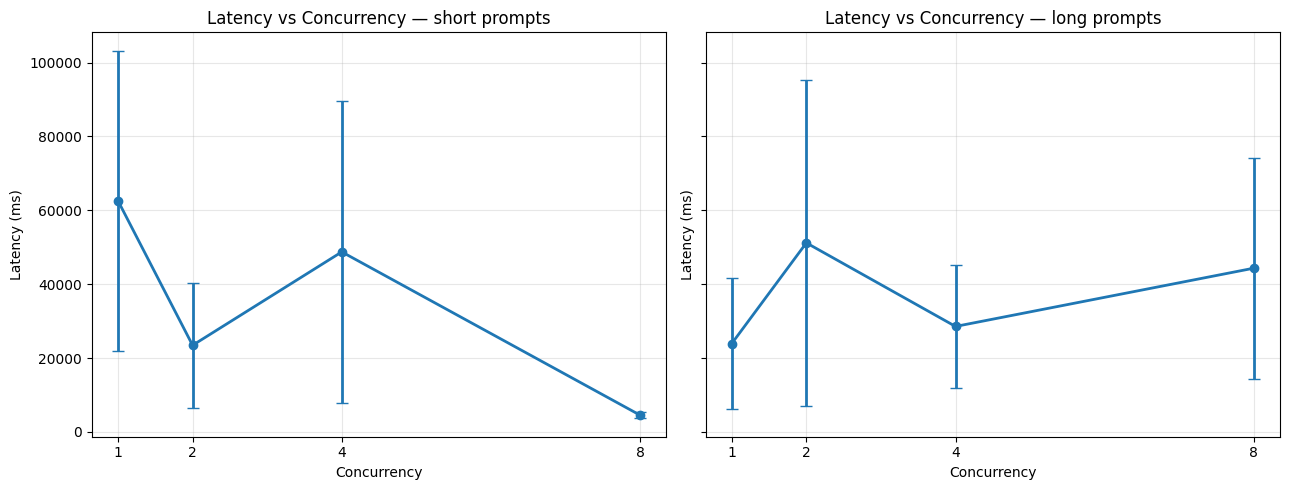

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, prompt_type in zip(axes, ["short", "long"]):
    subset = df[df["prompt_type"] == prompt_type]
    grouped = subset.groupby("concurrency")["latency_ms"].agg(["mean", "std"]).reset_index()
    ax.errorbar(
        grouped["concurrency"], grouped["mean"], yerr=grouped["std"],
        marker="o", capsize=4, linewidth=2,
    )
    ax.set_xlabel("Concurrency")
    ax.set_ylabel("Latency (ms)")
    ax.set_title(f"Latency vs Concurrency — {prompt_type} prompts")
    ax.set_xticks(sorted(subset["concurrency"].unique()))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. TTFT Distribution

Time-to-first-token is the most user-visible latency metric in streaming
applications.  A tight distribution means predictable perceived
responsiveness.

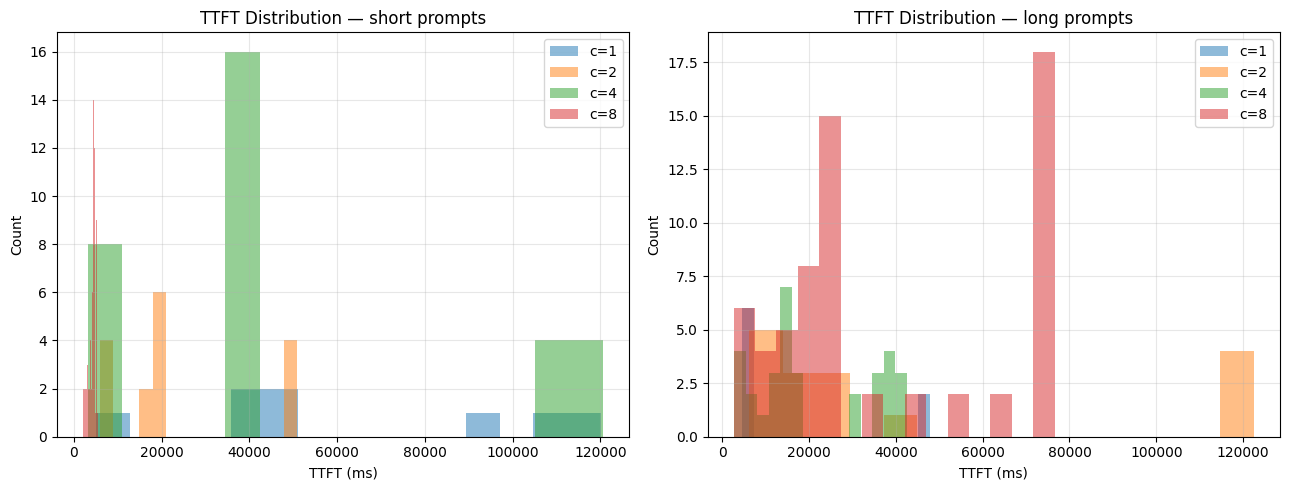

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, prompt_type in zip(axes, ["short", "long"]):
    subset = df[df["prompt_type"] == prompt_type]
    for conc in sorted(subset["concurrency"].unique()):
        vals = subset[subset["concurrency"] == conc]["ttft_ms"]
        ax.hist(vals, bins=15, alpha=0.5, label=f"c={conc}")
    ax.set_xlabel("TTFT (ms)")
    ax.set_ylabel("Count")
    ax.set_title(f"TTFT Distribution — {prompt_type} prompts")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Throughput Comparison (Short vs Long)

Tokens-per-second should stay roughly constant regardless of prompt length
once generation begins, because the auto-regressive decode cost is dominated
by the per-token step.  However, longer prompts incur a heavier prefill
phase which can reduce *effective* throughput when measured end-to-end.

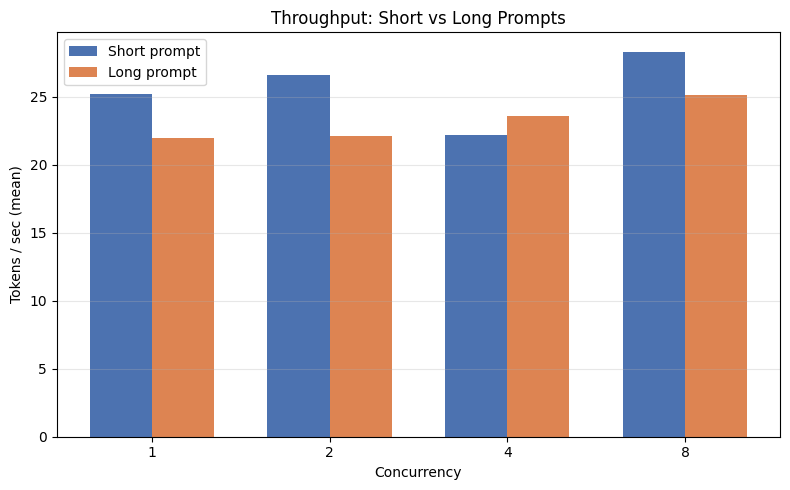

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

grouped = df.groupby(["concurrency", "prompt_type"])["tokens_per_sec"].mean().unstack()
x = np.arange(len(grouped.index))
width = 0.35

bars_short = ax.bar(x - width / 2, grouped["short"], width, label="Short prompt", color="#4C72B0")
bars_long  = ax.bar(x + width / 2, grouped["long"],  width, label="Long prompt",  color="#DD8452")

ax.set_xlabel("Concurrency")
ax.set_ylabel("Tokens / sec (mean)")
ax.set_title("Throughput: Short vs Long Prompts")
ax.set_xticks(x)
ax.set_xticklabels(grouped.index)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Latency Percentiles (P50 / P95 / P99)

Tail latencies matter in production.  The gap between P50 and P99 reveals
how much variance the system introduces under load.

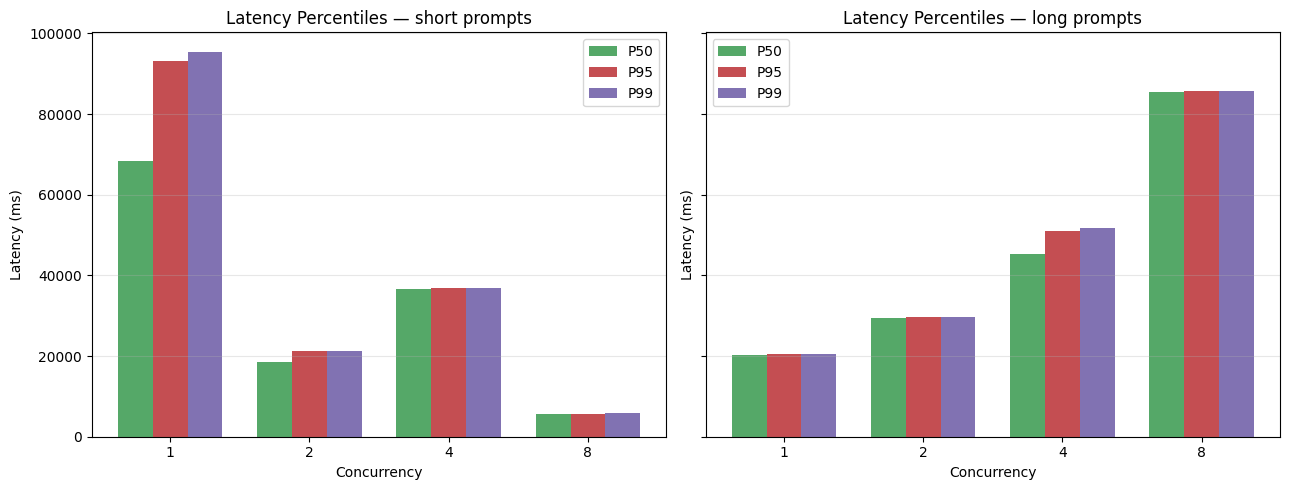

In [5]:
# Use the per-config percentile values (they are repeated per row, so just
# take the first row of each group).
pct = (
    df.groupby(["concurrency", "prompt_type"])[["p50_ms", "p95_ms", "p99_ms"]]
    .first()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, prompt_type in zip(axes, ["short", "long"]):
    sub = pct[pct["prompt_type"] == prompt_type]
    x = np.arange(len(sub))
    w = 0.25
    ax.bar(x - w, sub["p50_ms"], w, label="P50", color="#55A868")
    ax.bar(x,     sub["p95_ms"], w, label="P95", color="#C44E52")
    ax.bar(x + w, sub["p99_ms"], w, label="P99", color="#8172B2")
    ax.set_xlabel("Concurrency")
    ax.set_ylabel("Latency (ms)")
    ax.set_title(f"Latency Percentiles — {prompt_type} prompts")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["concurrency"])
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Cache Effect

Ollama can re-use the KV cache between requests for the same prompt prefix.
When caching is disabled we expect higher TTFT because the full prefill must
be recomputed every time.

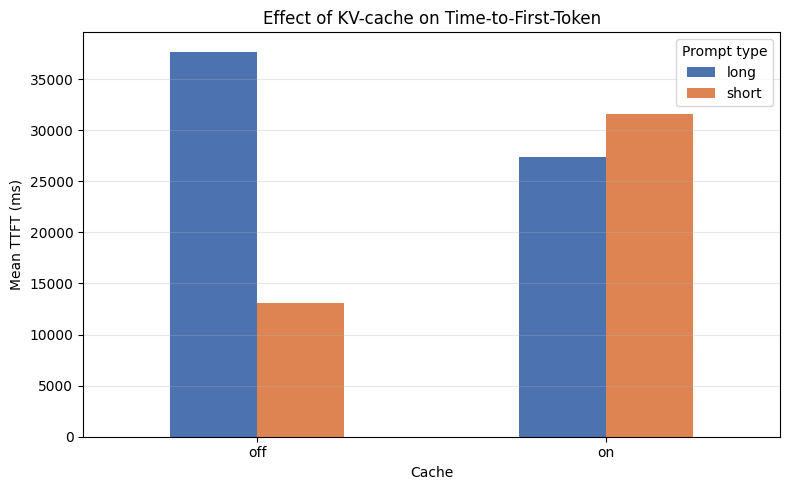

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

cache_group = df.groupby(["cache", "prompt_type"])["ttft_ms"].mean().unstack()
cache_group.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])

ax.set_xlabel("Cache")
ax.set_ylabel("Mean TTFT (ms)")
ax.set_title("Effect of KV-cache on Time-to-First-Token")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Prompt type")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

| Observation | Explanation |
|---|---|
| Latency scales roughly linearly with concurrency | Ollama serialises inference on one model instance, so concurrent requests queue behind each other. |
| TTFT is lower for short prompts | Shorter prefill phase means the model reaches the first generated token faster. |
| Throughput (tok/s) is similar for short and long prompts | Once generation starts, the per-token decode speed is largely independent of context length at these sizes. |
| P99 latency diverges from P50 under higher concurrency | Queuing effects create a long tail; the last request in a batch waits for all preceding ones. |
| Disabling the KV cache increases TTFT | Without cache reuse, the full prompt must be re-processed on every request. |